Here, the primary aluminium production capacity and its associated energy demand and emissions are modelled. Starting point is the stock of the smelter capacity. 

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dynamic_stock_model import DynamicStockModel

In [22]:
#thigs that need to be changed/entered when running the model:
#Excel file and sheet name (next cell)
#lifetime (next cell)

In the cell below, the mean lifetime and standard deviation of the smelters can be adapted. Also, the demand scenario (as described in the manuscript, we use 2 different demand scenarios) can be changed, because for each demand scenario, another excel file with the input data is used. Use "_high demand" as a suffix for the filename to read the high demand scenario and no suffix to read the reference demand scenario.

In [23]:
#Lifetime 40 (13 std dev) vs. 50 (17 std.dev.) years
lifetime_smelter = 40
std_dev_smelter = 13

#high demand (_high demand) vs. reference (0, because basic scenario) vs. "_Highest improvement"
Demand_scenario= ''

#here, it can be changed if we read the primary produciton without  ("S-") or with improved sorting and recycling technologies ("S+")
'_S+'
scrap_scenario = '_S-'

#smelter lifetime
LD = str(lifetime_smelter) + Demand_scenario + scrap_scenario

Here, the data table is read to start the stock-driven model based on the primary aluminium production for each year. 

In [24]:
file = "Technology stocks/Smelter/Capacity data python" + Demand_scenario + scrap_scenario + ".xlsx"
data = pd.read_excel(file, sheet_name = 'Technologies_PB_' +str(lifetime_smelter), usecols='A:BB', skiprows=1, nrows=151)
#Input data (smelter capacity stocks) stays the same
data.reset_index(drop=True, inplace=True)
data.fillna(0, inplace=True)
data

,year,Primary Al (model) [kt],Mean value utilisation rate (reg)\n(based on geniSim and USGS),Smelter Capacity Stock (total),share Prebake (IAI),share Soderberg (IAI),Total inflows smelter,Total outflows smelter,Inflow-share PB,Inflow-share SS,...,Energy demand mean IAI,Energy demand total smelter [GWh] (S1),Energy demand total smelter [GWh] (S2),Energy demand total smelter [GWh] (BAU),GHG-emissions indirect (S1) [Mt],GHG-emissions indirect (S2) [Mt],"GHG-emissions indirect (BAU, ef.const.) [Mt]","GHG-emissions indirect (BAU, ef.red.) [Mt]","GHG-emissions indirect (S1, ef.const.) [Mt]","GHG-emissions indirect (S2, ef.const.) [Mt]"
0,1900,0.000000,0.87,0.000000,0.631835,0.368165,0.000000,0.000000,1.00,0.00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1901,0.183590,0.87,0.211023,0.631835,0.368165,0.211244,0.000221,1.00,0.00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1902,0.218913,0.87,0.251624,0.631835,0.368165,0.040708,0.000107,1.00,0.00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1903,0.260710,0.87,0.299667,0.631835,0.368165,0.048187,0.000144,1.00,0.00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,1904,0.310180,0.87,0.356529,0.631835,0.368165,0.057053,0.000191,1.00,0.00,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,93897.801183,0.90,104330.890203,0.000000,0.000000,2567.160167,2354.588240,0.98,0.02,...,13.381404,1.219498e+06,1.201400e+06,1.256484e+06,184.882606,182.138805,762.760159,190.489911,740.307374,729.320641
147,2047,94048.455994,0.90,104498.284438,0.000000,0.000000,2578.608587,2411.214351,0.98,0.02,...,13.355973,1.217348e+06,1.197025e+06,1.256109e+06,163.231850,160.506780,762.532059,168.429134,739.002310,726.665053
148,2048,94164.784244,0.90,104627.538048,0.000000,0.000000,2592.441325,2463.187714,0.98,0.02,...,13.331148,1.214799e+06,1.192112e+06,1.255325e+06,141.609874,138.965171,762.056121,146.333930,737.454884,723.682195
149,2049,94253.883963,0.90,104726.537736,0.000000,0.000000,2609.223813,2510.224125,0.98,0.02,...,13.306954,1.211951e+06,1.186755e+06,1.254232e+06,120.047530,117.551851,761.392873,124.235630,735.725604,720.430534


Here, the parameters are read (from parameter sheet in the excel files)

In [25]:
file = "Technology stocks/Smelter/Capacity data python" + Demand_scenario + scrap_scenario + ".xlsx"
data_parameter = pd.read_excel(file, sheet_name = 'Tech.Parameter', usecols='A:O', nrows=151)
#Input data (smelter capacity stocks) stays the same
data_parameter.reset_index(drop=True, inplace=True)
data_parameter.fillna(0, inplace=True)
data_parameter

,year,Inflow-share PB,Inflow-share SS,Inflow-share Inert Anodes?,comment,Stock share PB (IAI,Stock share SS (IAI,Unnamed: 7,global Al production (USGS) [kt],Mean PFC intensity [t CO2/tAl],Direct emissions Anode consumption [t CO2/tAl],BAT energy demand (S1) [kWh/kg],BAT energy demand (S2) [kWh/kg],BAT energy demand (BAU) [kWh/kg],GHG [kt CO2e/GWh] for smelter electr. Mix
0,1900,1.00,0.00,0.0,0,1.0,0.0,0.0,6.8,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
1,1901,1.00,0.00,0.0,0,1.0,0.0,0.0,6.8,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
2,1902,1.00,0.00,0.0,0,1.0,0.0,0.0,7.9,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
3,1903,1.00,0.00,0.0,0,1.0,0.0,0.0,8.5,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
4,1904,1.00,0.00,0.0,0,1.0,0.0,0.0,10.0,0.000000,0.0,33.047161,33.047161,33.047161,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.158065,1.4,12.140000,11.228000,12.959195,0.151605
147,2047,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.143548,1.4,12.140000,11.171000,12.959195,0.134088
148,2048,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.129032,1.4,12.140000,11.114000,12.959195,0.116571
149,2049,0.98,0.02,0.0,0,0.0,0.0,0.0,0.0,0.114516,1.4,12.140000,11.057000,12.959195,0.099053


Now we run the dynamic stock-driven model to calculate in- and outflows of the smelters. We do this first for the total smelter capacity and differentiate then between the Prebake and Søderberg cells.

In [26]:
#DSM Smelter Model
DSM_smelter = DynamicStockModel(t=data['year'],
                         s=data['Smelter Capacity Stock (total)'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_smelter]),
                             'StdDev': np.array([std_dev_smelter]) 
                             }
                            )

DSM_smelter.compute_stock_driven_model() 
DSM_smelter.compute_outflow_total()

data['Total inflows smelter'] = DSM_smelter.i
data['Total outflows smelter'] = DSM_smelter.o

In [27]:
#plotting some data if needed
#data[data['year']>2030]


In [28]:
#saving the time-cohort matrix
stock_cohort = DSM_smelter.s_c
#stock_cohort

In [29]:
#reading the inflow share of PB and SS smelters
inflow_share_PB=np.array([data['Inflow-share PB']])
inflow_share_SS=np.array([data['Inflow-share SS']])

From the total inflows of smelter capacity we derive the inflows for both, the Prebake (PB) and the Søderberg (SS) cells based on the inflow share.

In [30]:
data['Inflows PB'] = np.multiply(data['Total inflows smelter'], data['Inflow-share PB'])
data['Inflows SS'] = np.multiply(data['Total inflows smelter'], data['Inflow-share SS'])

We can also calculate the stock of PB and SS for each year based on the total time-cohort matrix, the inflow shares and summing the time-cohort matrix for both technologies over the cohorts. This way we do not have to rerun the DSM model for both technologies.

In [31]:
s_c_PB = stock_cohort*inflow_share_PB
s_c_SS = stock_cohort*inflow_share_SS

#np.sum([[0, 1], [0, 5]], axis=0)
#array([0, 6])
data['Stock PB (calc.)'] = np.sum(s_c_PB, axis=1)
data['Stock SS (calc.)'] = np.sum(s_c_SS, axis=1)


In [32]:
def technology_penetration_share (column_name_inflow_share, launch_t, launch_lev, rampup_t, rampup_lev):
    '''
    function to calculate the technology penetration resp. in which year what share of the inflows are the new technology
    parameters:
        column_name_inflow_share: name of the colum in the dataframe to write the calculated shares there
        launch_t: launch year of new technology
        launch_lev: lauch share of new technology (how many of the new inflowing capacity are with the new technology 
                    in the year when the technology is first used?)
        rampup_t: ramp up year (in which year do new techn. reach its max. share of the new inflows)
        rampup_lev: ramp up level (max share of new technology)'''

    data.loc[data['year']<launch_t, column_name_inflow_share] = 0
    data.loc[data['year']==launch_t, column_name_inflow_share] = launch_lev

    if rampup_t>launch_t:
        data.loc[data['year']>launch_t, column_name_inflow_share] = \
            ( (rampup_lev-launch_lev)/(rampup_t-launch_t) ) * (data.year-launch_t)+launch_lev
    else: 
        data.loc[data['year']>launch_t, column_name_inflow_share] = launch_lev
        rampup_lev=launch_lev
    
    data.loc[data['year']>=rampup_t, column_name_inflow_share] = rampup_lev
    
    #print penetration share figure
    '''data_2020_2050=data[data['year'] > 2019]
    plt.figure(figsize=(8, 5))
    plt.plot(data_2020_2050['year'], data_2020_2050[column_name_inflow_share], 'g--', label=column_name_inflow_share)
    plt.title(column_name_inflow_share)
    plt.xlabel('Year')
    plt.ylabel('Inflow share [%]')
    plt.legend(loc='best')'''

In [33]:
#compute DSM model for PB smelter for implementation of Inert Anodes in PB smelters
DSM_PB = DynamicStockModel(t=data['year'],
                         s=data['Stock PB (calc.)'],
                         lt={'Type': 'Normal', 
                             'Mean': np.array([lifetime_smelter]),
                             'StdDev': np.array([std_dev_smelter]) 
                             }
                            )

DSM_PB.compute_stock_driven_model()
DSM_PB.compute_outflow_total()

    
stock_cohort_PB = DSM_PB.s_c
#stock_cohort_PB


In [34]:
def compute_technology_stock_share (column_name_new_stock, column_name_new, column_name_rest, column_name_inflow_share, column_name_inflows, column_name_stock_total, column_name_retrofit, scenario_name):
    
    '''
    new technology: here inert anodes
    column_name_new_stock: column name of stock of new technology
    column_name_new: column name of stock share of new technology
    column_name_rest: column name of stock share of rest/old technology
    column_name_inflow_share: should be the same as in the corresponding technology_penetration_share function
    cloumn_name_inflows: column name of Inflows of total technology (new+state of the art/old)
    column_name_retrofit: column name where the amount of retrofit is written
    scenario_name: name of scenario
    '''

    #compute stock cohort matrix for IA smelter
    #np.array([data[column_name_inflow_share]])
    s_c_IA = stock_cohort_PB * np.array([data[column_name_inflow_share]])
    
    #compute stock of IA smelter
    #data[column_name_new_stock] = np.sum(s_c_IA, axis=1)
    p_stock_new_before_retrofit = np.sum(s_c_IA, axis=1)
    
    #compute stock share of IAs without/before retrofitting
    p_stock_share_new_before_retrofit = np.divide(p_stock_new_before_retrofit, data['Smelter Capacity Stock (total)'])

    #compute retrofitting and stock share of IAs after retrofitting
    p_cumulative_retrofit = np.cumsum(data[column_name_retrofit])
    p_stock_share_new_total = np.add(p_stock_share_new_before_retrofit, (np.divide(p_cumulative_retrofit, data['Smelter Capacity Stock (total)'])))
    data[column_name_new] = p_stock_share_new_total
    data[column_name_rest]=1-data[column_name_new]
    
    data[column_name_new_stock]= np.add(p_stock_new_before_retrofit, p_cumulative_retrofit)
    
    #plotting
    #data_2020_2050=data[data['year'] > 2019]
    ##fig, ax1 = plt.subplots(figsize=(8, 5)) 
    #ax1.set_ylabel('Share in stock and inflow', fontsize=12)
    #ax1.stackplot(data_2020_2050['year'], data_2020_2050[column_name_new], data_2020_2050[column_name_rest], \
                 # labels=['New technology','Rest'])
    #ax1.plot(data_2020_2050['year'], data_2020_2050[column_name_inflow_share], 'g--', label='Inflow-share ')
    #plt.legend(loc='lower right', fontsize=12)

    #ax2 =ax1.twinx()
    #ax2.plot(data_2020_2050['year'], data_2020_2050[column_name_retrofit], 'r--', label='yearly retrofit')
    #ax2.set_ylabel('yearly retrofit [kt]', fontsize=12)
    #plt.ylim([0,3000])
    #plt.legend(loc='upper right', fontsize=12)
    #plt.title('Stock-shares IA ' + scenario_name, pad=10, fontsize=12)

    #scenario_name_save=scenario_name.replace('.', '-')

    #plt.savefig(('Python exports/Figures/Stock-shares technologies ' + scenario_name_save+ ' (L='+str(lifetime_smelter) + ')'), dpi=300)
    plt.savefig(('Python exports/Figures/Direct emissions smelter'+ ' (L='+str(lifetime_smelter) + ')'), dpi=300)

In [35]:
column_name_retrofit=data['Retrofit Sx.1']
p_cumulative_retrofit = np.cumsum(column_name_retrofit)

In [36]:
#calculating additional retrofit share (Inert Anodes)
def technology_retrofit (column_name_retrofit, launch_t, retrofit_t):
    '''
    function to set the amount of retrofitting with new technology
    parameter:
        column_name_retrofit_share: name of column where the retrofit share should be written
        launch_t: launch year of new technology (should be the same as in the technology_penetration_share function)
        x_retrofit_t: yearly share of stock which is retrofitted
    '''
    data.loc[data['year']<launch_t, column_name_retrofit] = 0
    data.loc[data['year']>=launch_t, column_name_retrofit] = retrofit_t

In [37]:
technology_penetration_share (column_name_inflow_share='Inflow-share IA in PB - S1',
                              launch_t=2030,
                              launch_lev=1, 
                              rampup_t=2040, 
                              rampup_lev=1  )
#data['Inflow-share IA in PB - S1 (best)']

In [38]:
technology_penetration_share (column_name_inflow_share='Inflow-share IA in PB - S2',
                              launch_t=2030,
                              launch_lev=0.2, 
                              rampup_t=2040, 
                              rampup_lev=0.8  )

#data[data['year']>2028] 

In [39]:
technology_retrofit (column_name_retrofit='Retrofit Sx.1',
                     launch_t=2030,
                     retrofit_t=0
)

technology_retrofit (column_name_retrofit='Retrofit Sx.2',
                     launch_t=2030,
                     retrofit_t=1000
)

technology_retrofit (column_name_retrofit='Retrofit Sx.3',
                     launch_t=2030,
                     retrofit_t=2000
)

In [40]:
#computing best case and plotting (S1.1-S1.3)


#S1.1: no retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S1.1', 
                               column_name_new='Stock share Inert Anode Smelter S1.1', 
                               column_name_rest='Stock share rest S1.1', 
                               column_name_inflow_share='Inflow-share IA in PB - S1', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.1',
                               scenario_name='S_IA_1.1 (High IA penetration without retrofitting)'
)


<Figure size 432x288 with 0 Axes>

In [41]:
#S1.2: 1000kt yearly retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S1.2', 
                                column_name_new='Stock share Inert Anode Smelter S1.2', 
                               column_name_rest='Stock share rest S1.2', 
                               column_name_inflow_share='Inflow-share IA in PB - S1', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.2',
                               scenario_name='S_IA_1.2 (High IA penetration + 1000kt yearly retrofitting)'
)

<Figure size 432x288 with 0 Axes>

In [42]:
#S1.3: 2000kt yearly retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S1.3', 
                                column_name_new='Stock share Inert Anode Smelter S1.3', 
                               column_name_rest='Stock share rest S1.3', 
                               column_name_inflow_share='Inflow-share IA in PB - S1', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.3',
                               scenario_name='S_IA_1.3 (High IA penetration + 2000kt yearly retrofitting)'
)

<Figure size 432x288 with 0 Axes>

In [43]:
#computing realistic case and plotting (S2.1-S2.3)

#S2.1: no retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S2.1', 
                                column_name_new='Stock share Inert Anode Smelter S2.1', 
                               column_name_rest='Stock share rest S2.1', 
                               column_name_inflow_share='Inflow-share IA in PB - S2', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.1',
                               scenario_name='S_IA_2.1 (Moderate IA penetration without retrofitting)'
)
#S2.2: 1000kt yearly retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S2.2',
                                column_name_new='Stock share Inert Anode Smelter S2.2', 
                               column_name_rest='Stock share rest S2.2', 
                               column_name_inflow_share='Inflow-share IA in PB - S2', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.2',
                               scenario_name='S_IA_2.2 (Moderate IA penetration + 1000kt yearly retrofitting'
)
#S2.3: 2000kt yearly retrofitting
compute_technology_stock_share(column_name_new_stock='Stock Inert Anode Smelter S2.3',
                                column_name_new='Stock share Inert Anode Smelter S2.3', 
                               column_name_rest='Stock share rest S2.3', 
                               column_name_inflow_share='Inflow-share IA in PB - S2', 
                               column_name_inflows='Inflows PB',
                               column_name_stock_total='Smelter stock PB',
                               column_name_retrofit='Retrofit Sx.3',
                               scenario_name='S_IA_2.3 (Moderate IA penetration + 2000kt yearly retrofitting'
)
data['Stock share Inert Anode Smelter S2.3']

0           NaN
1      0.000000
2      0.000000
3      0.000000
4      0.000000
         ...   
146    0.574635
147    0.611786
148    0.649079
149    0.686511
150    0.724066
Name: Stock share Inert Anode Smelter S2.3, Length: 151, dtype: float64

<Figure size 432x288 with 0 Axes>

In [44]:
#computing direct emissions from 2020 to 2050

#Direct emissions Anode consumption =1.4 tCO2/tAl (ref. )
#Direct emissions today PFC=0.55 (modern plant 0.1) tCO2/tAl (ref. IAI)
#unit=[tCO2/tAl]
direct_e_specific_total= np.add(data_parameter['Mean PFC intensity [t CO2/tAl]'], data_parameter['Direct emissions Anode consumption [t CO2/tAl]'])

data.loc[data['year']>=2020, 'Direct emissions (no change) [Mt CO2eq]'] = np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total) / 1000

#scenario 1: 100% inflow share for new smelter
data.loc[data['year']>=2020, 'Direct emissions S1.1 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S1.1']) / 1000
data.loc[data['year']>=2020, 'Direct emissions S1.2 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S1.2']) / 1000
data.loc[data['year']>=2020, 'Direct emissions S1.3 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S1.3']) / 1000 

#scenario 2: 20-80% linear increasing inflow share for new smelter
data.loc[data['year']>=2020, 'Direct emissions S2.1 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S2.1']) / 1000
data.loc[data['year']>=2020, 'Direct emissions S2.2 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S2.2']) / 1000 
data.loc[data['year']>=2020, 'Direct emissions S2.3 [Mt CO2eq]'] = np.multiply(np.multiply(data['Primary Al (model) [kt]'], direct_e_specific_total), data['Stock share rest S2.3']) / 1000 
         
    

In [45]:
data_2020_2050=data[data['year'] > 2019]
data_2020_2050['Stock share rest S2.2']


120    1.000000
121    1.000000
122    1.000000
123    1.000000
124    1.000000
125    1.000000
126    1.000000
127    1.000000
128    1.000000
129    1.000000
130    0.986088
131    0.969083
132    0.951123
133    0.930201
134    0.908285
135    0.885382
136    0.861472
137    0.836520
138    0.810494
139    0.783344
140    0.755029
141    0.726992
142    0.699149
143    0.671422
144    0.643745
145    0.616058
146    0.588308
147    0.560465
148    0.532517
149    0.504462
150    0.476312
Name: Stock share rest S2.2, dtype: float64

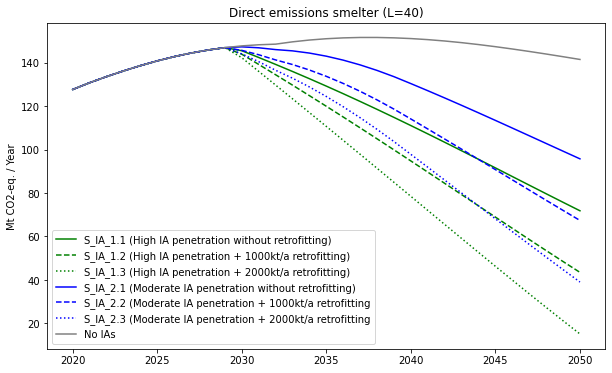

In [46]:
data_2020_2050=data[data['year'] >= 2020]
plt.figure(figsize=(10, 6))

#PFCs are reducing to BAT from 2020 with 0,01 tCO2eq/tAl

#scenario 1: 100% inflow share for new smelter
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S1.1 [Mt CO2eq]'], color='green', linestyle='-', label='S_IA_1.1 (High IA penetration without retrofitting)')
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S1.2 [Mt CO2eq]'], color='green', linestyle='--', label='S_IA_1.2 (High IA penetration + 1000kt/a retrofitting)')
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S1.3 [Mt CO2eq]'], color='green', linestyle=':', label='S_IA_1.3 (High IA penetration + 2000kt/a retrofitting)')


#scenario 2: 20-80% linear increasing inflow share for new smelter
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S2.1 [Mt CO2eq]'], color='blue', linestyle='-', label='S_IA_2.1 (Moderate IA penetration without retrofitting)')
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S2.2 [Mt CO2eq]'], color='blue', linestyle='--', label='S_IA_2.2 (Moderate IA penetration + 1000kt/a retrofitting')
plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions S2.3 [Mt CO2eq]'], color='blue', linestyle=':', label='S_IA_2.3 (Moderate IA penetration + 2000kt/a retrofitting')

plt.plot(data_2020_2050['year'], data_2020_2050['Direct emissions (no change) [Mt CO2eq]'], color='grey', label='No IAs')
plt.legend(loc='best')
plt.ylabel('Mt CO2-eq. / Year')


plt.title('Direct emissions smelter'+ ' (L='+str(lifetime_smelter) + ')')
plt.savefig(('Python exports/Figures/Direct emissions smelter'+ ' (L='+str(lifetime_smelter) + ')'), dpi=300)

In [47]:
#compute impact of BAT retrofitting
retrofit_t=1000

#compute cumulative Inflows from 2020-2050
data_2020_2050=data[data['year'] >= 2020]
data.loc[data['year']>=2020, 'cum.Inflows 2020-2050']=data_2020_2050['Total inflows smelter'].cumsum()

#parameter for years with retrofitting from 2020, with considering the new inflows since 2020
p_years_retrofitting=round((data['Smelter Capacity Stock (total)'][150]-data['cum.Inflows 2020-2050'][150])/retrofit_t)

data.loc[(data['year']>=2020) & (data['year']<2020+p_years_retrofitting), 'Retrofit BAT.1']=retrofit_t



#compute stock share new in year t (share of stock which is new built since 2020 and uses BAT technology)
'''data.loc[data['year']>=2020, 'Stock share new']=np.divide(data['cum.Inflows 2020-2050'], data['Smelter Capacity Stock (total)'])

#setting lower yearly retrofit at 1000
data.loc[data['year']>=2020, 'Retrofit BAT.1']=1000
p_cum_retrofitted_t= data['Retrofit BAT.1'].cumsum()

data.loc[data['year']>=2020, 'Stock share retrofitted BAT.1']=np.divide(p_cum_retrofitted_t, data['Smelter Capacity Stock (total)'])
#data['Stock share retrofitted BAT.1']

data.loc[(data['Stock share new']+data['Stock share retrofitted BAT.1'])>=1, 'Retrofit BAT.1']=0
p_cum_retrofitted_t= data['Retrofit BAT.1'].cumsum()
data.loc[data['year']>=2020, 'Stock share retrofitted BAT.1']=np.divide(p_cum_retrofitted_t, data['Smelter Capacity Stock (total)'])
new=data['Stock share new']+data['Stock share retrofitted BAT.1']
new'''
#data['Retrofit BAT.1']

"data.loc[data['year']>=2020, 'Stock share new']=np.divide(data['cum.Inflows 2020-2050'], data['Smelter Capacity Stock (total)'])\n\n#setting lower yearly retrofit at 1000\ndata.loc[data['year']>=2020, 'Retrofit BAT.1']=1000\np_cum_retrofitted_t= data['Retrofit BAT.1'].cumsum()\n\ndata.loc[data['year']>=2020, 'Stock share retrofitted BAT.1']=np.divide(p_cum_retrofitted_t, data['Smelter Capacity Stock (total)'])\n#data['Stock share retrofitted BAT.1']\n\ndata.loc[(data['Stock share new']+data['Stock share retrofitted BAT.1'])>=1, 'Retrofit BAT.1']=0\np_cum_retrofitted_t= data['Retrofit BAT.1'].cumsum()\ndata.loc[data['year']>=2020, 'Stock share retrofitted BAT.1']=np.divide(p_cum_retrofitted_t, data['Smelter Capacity Stock (total)'])\nnew=data['Stock share new']+data['Stock share retrofitted BAT.1']\nnew"

In [48]:
#data.loc[(data['Stock share new']+data['Stock share retrofitted BAT.1'])>=1, 'Retrofit BAT.1']=0
#data['Retrofit BAT.1']

e_mean_S1 = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (S1) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)
e_mean_S2 = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (S2) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)
e_mean_BAU = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (BAU) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)

C:\Users\Morit\AppData\Local\Temp/ipykernel_18000/2800024899.py:4: RuntimeWarning: invalid value encountered in true_divide
  e_mean_S1 = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (S1) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)
C:\Users\Morit\AppData\Local\Temp/ipykernel_18000/2800024899.py:5: RuntimeWarning: invalid value encountered in true_divide
  e_mean_S2 = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (S2) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)
C:\Users\Morit\AppData\Local\Temp/ipykernel_18000/2800024899.py:6: RuntimeWarning: invalid value encountered in true_divide
  e_mean_BAU = np.einsum('tc,c->t', DSM_smelter.s_c, data_parameter['BAT energy demand (BAU) [kWh/kg]'])/ np.sum(DSM_smelter.s_c, axis=1)


In [49]:
#starting from 2021( = 121 in the array)
e_mean_S1[120:]


array([14.21442551, 14.17393161, 14.12869093, 14.08426609, 14.04048817,
       13.99743428, 13.95541351, 13.91452592, 13.87452906, 13.8353618 ,
       13.79702914, 13.7428359 , 13.69072716, 13.63046278, 13.57272697,
       13.51719173, 13.46352782, 13.41144077, 13.36071448, 13.31114277,
       13.26258479, 13.21493043, 13.16809241, 13.12198669, 13.07655369,
       13.03174001, 12.98750568, 12.94384262, 12.90078206, 12.8583639 ,
       12.81664738])

In [50]:
#data['Energy demand mean (S1)']=e_mean_S1
data.loc[data['year']<=2020, 'Energy demand mean (S1)'] = data['Energy demand mean IAI']
data.loc[data['year']>2020, 'Energy demand mean (S1)'] = e_mean_S1[121:]

data.loc[data['year']<=2020, 'Energy demand mean (S2)'] = data['Energy demand mean IAI']
data.loc[data['year']>2020, 'Energy demand mean (S2)'] = e_mean_S2[121:]

data.loc[data['year']<=2020, 'Energy demand mean IAI'] = data['Energy demand mean IAI']
data.loc[data['year']>2020, 'Energy demand mean IAI'] = e_mean_BAU[121:]




In [51]:
data['Energy demand mean (S1)'][119]

14.255

In [52]:
#calculating total energy demand smelter
data_1990_2050=data[data['year'] >= 1990]
E_demand_S1 = np.multiply( data_1990_2050['Energy demand mean (S1)'], data_1990_2050['Primary Al (model) [kt]'])
data['Energy demand total smelter [GWh] (S1)'] = E_demand_S1

E_demand_S2 = np.multiply(data_1990_2050['Energy demand mean (S2)'], data_1990_2050['Primary Al (model) [kt]' ])
data['Energy demand total smelter [GWh] (S2)'] = E_demand_S2

#Energy efficiency stays at 2020 level
E_demand_BAU = np.multiply(data_1990_2050['Energy demand mean IAI'], data_1990_2050['Primary Al (model) [kt]' ])
data['Energy demand total smelter [GWh] (BAU)']= E_demand_BAU

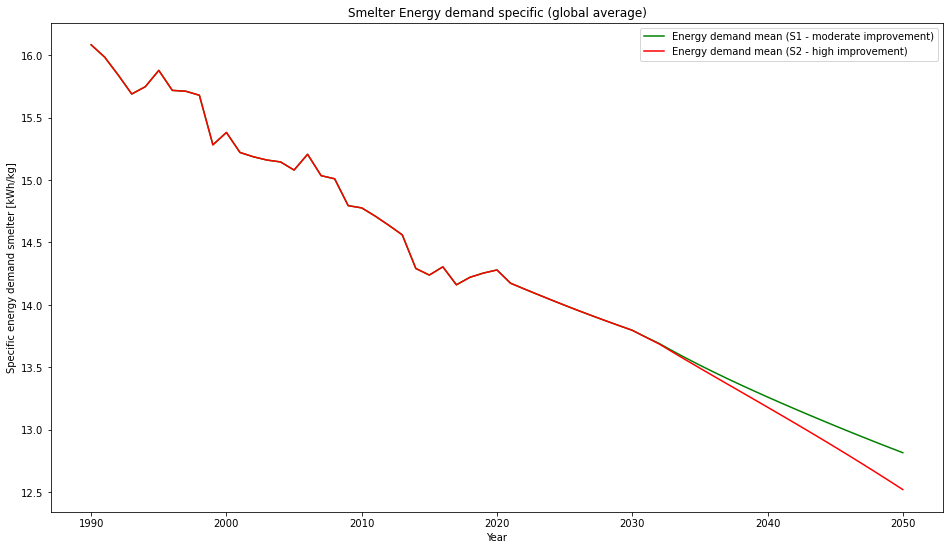

In [53]:
plt.figure(figsize=(16, 9))
plt.plot(data_1990_2050.year, data_1990_2050['Energy demand mean (S1)'], 'g', label='Energy demand mean (S1 - moderate improvement)')
plt.plot(data_1990_2050.year, data_1990_2050['Energy demand mean (S2)'], 'r', label='Energy demand mean (S2 - high improvement)')


plt.title('Smelter Energy demand specific (global average)')
plt.xlabel('Year')
plt.ylabel('Specific energy demand smelter [kWh/kg]')
plt.legend(loc='best')

plt.savefig(('Python exports/Figures/Smelter Energy demand specific (global average)'), dpi=300)
#with history data from the IAI             

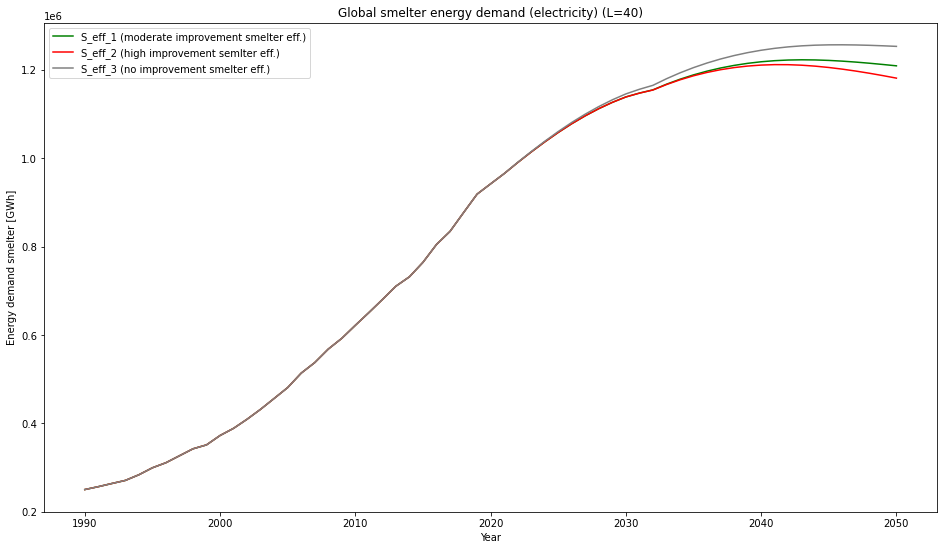

In [54]:
                                                                        
plt.figure(figsize=(16, 9))
plt.plot(data_1990_2050.year, E_demand_S1, 'g', label='S_eff_1 (moderate improvement smelter eff.)')
plt.plot(data_1990_2050.year, E_demand_S2, 'r', label='S_eff_2 (high improvement semlter eff.)')
plt.plot(data_1990_2050.year, E_demand_BAU, 'grey', label='S_eff_3 (no improvement smelter eff.)')
plt.title('Global smelter energy demand (electricity)')
plt.xlabel('Year')
plt.ylabel('Energy demand smelter [GWh]')
plt.legend(loc='best')

plt.title('Global smelter energy demand (electricity)' + ' (L='+str(lifetime_smelter) + ')')
plt.savefig(('Python exports/Figures/Global smelter energy demand (electricity)'+ ' (L='+str(lifetime_smelter) + ')'), dpi=300)

In [55]:
#calculating indirect GHG emissions smelter
data_parameter_1990_2050 = data_parameter[data_parameter['year'] >= 1990]
#emission factor following the IAI forecast for electricity mix and historical data
ef=data_parameter_1990_2050 ['GHG [kt CO2e/GWh] for smelter electr. Mix']

#together with decrease of emission factor (following IAI forecast)
data['GHG-emissions indirect (S1) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S1)'], ef)/1000
data['GHG-emissions indirect (S2) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S2)'], ef)/1000

#BAU in general: no efficiency improvements
#BAU (ef constant): no emission factor decrease from today to 2050
data.loc[data['year']<=2020, 'GHG-emissions indirect (BAU, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (BAU)'], ef)/1000
data.loc[data['year']>2020, 'GHG-emissions indirect (BAU, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (BAU)'], ef[120])/1000

data.loc[data['year']<=2020, 'GHG-emissions indirect (S1, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S1)'], ef)/1000
data.loc[data['year']>2020, 'GHG-emissions indirect (S1, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S1)'], ef[120])/1000

data.loc[data['year']<=2020, 'GHG-emissions indirect (S2, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S2)'], ef)/1000
data.loc[data['year']>2020, 'GHG-emissions indirect (S2, ef.const.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (S2)'], ef[120])/1000

#BAU (ef reduction): reduction of emission factor until 2050 to 0,0815 kt CO2/GWh
data['GHG-emissions indirect (BAU, ef.red.) [Mt]'] = np.multiply(data['Energy demand total smelter [GWh] (BAU)'], ef)/1000


data['GHG-emissions indirect (S2) [Mt]']

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
146    182.138805
147    160.506780
148    138.965171
149    117.551851
150     96.297223
Name: GHG-emissions indirect (S2) [Mt], Length: 151, dtype: float64

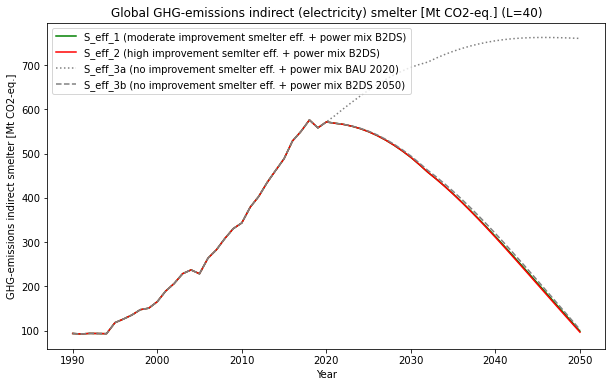

In [56]:
data_1990_2050=data[data['year'] >= 1990]
plt.figure(figsize=(10, 6))
plt.plot(data_1990_2050.year, data_1990_2050['GHG-emissions indirect (S1) [Mt]'], 'g', label='S_eff_1 (moderate improvement smelter eff. + power mix B2DS)')
plt.plot(data_1990_2050.year, data_1990_2050['GHG-emissions indirect (S2) [Mt]'], 'r', label='S_eff_2 (high improvement semlter eff. + power mix B2DS)')
plt.plot(data_1990_2050.year, data_1990_2050['GHG-emissions indirect (BAU, ef.const.) [Mt]'], 'grey',linestyle=':', label='S_eff_3a (no improvement smelter eff. + power mix BAU 2020)')
plt.plot(data_1990_2050.year, data_1990_2050['GHG-emissions indirect (BAU, ef.red.) [Mt]'], 'grey', linestyle='--', label='S_eff_3b (no improvement smelter eff. + power mix B2DS 2050)')
plt.title('GHG-emissions indirect smelter [Mt CO2-eq.]')
plt.xlabel('Year')
plt.ylabel('GHG-emissions indirect smelter [Mt CO2-eq.]')
plt.legend(loc='best')

plt.title('Global GHG-emissions indirect (electricity) smelter [Mt CO2-eq.]' + ' (L='+str(lifetime_smelter) + ')')
plt.savefig(('Python exports/Figures/Global GHG-emissions indirect (electricity) smelter'+\
             ' (L='+str(lifetime_smelter) + ')'), dpi=300)

In [57]:
data


,year,Primary Al (model) [kt],Mean value utilisation rate (reg)\n(based on geniSim and USGS),Smelter Capacity Stock (total),share Prebake (IAI),share Soderberg (IAI),Total inflows smelter,Total outflows smelter,Inflow-share PB,Inflow-share SS,...,GHG-emissions indirect (S1) [Mt],GHG-emissions indirect (S2) [Mt],"GHG-emissions indirect (BAU, ef.const.) [Mt]","GHG-emissions indirect (BAU, ef.red.) [Mt]","GHG-emissions indirect (S1, ef.const.) [Mt]","GHG-emissions indirect (S2, ef.const.) [Mt]",Inflows PB,Inflows SS,cum.Inflows 2020-2050,Retrofit BAT.1
0,1900,0.000000,0.87,0.000000,0.631835,0.368165,0.000000,0.000000,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN
1,1901,0.183590,0.87,0.211023,0.631835,0.368165,0.211244,0.000221,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.211244,0.000000,NaN,NaN
2,1902,0.218913,0.87,0.251624,0.631835,0.368165,0.040708,0.000107,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.040708,0.000000,NaN,NaN
3,1903,0.260710,0.87,0.299667,0.631835,0.368165,0.048187,0.000144,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.048187,0.000000,NaN,NaN
4,1904,0.310180,0.87,0.356529,0.631835,0.368165,0.057053,0.000191,1.00,0.00,...,NaN,NaN,NaN,NaN,NaN,NaN,0.057053,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,2046,93897.801183,0.90,104330.890203,0.000000,0.000000,2567.160167,2354.588240,0.98,0.02,...,184.882606,182.138805,762.760159,190.489911,740.307374,729.320641,2515.816964,51.343203,61430.700326,1000.0
147,2047,94048.455994,0.90,104498.284438,0.000000,0.000000,2578.608587,2411.214351,0.98,0.02,...,163.231850,160.506780,762.532059,168.429134,739.002310,726.665053,2527.036415,51.572172,64009.308913,1000.0
148,2048,94164.784244,0.90,104627.538048,0.000000,0.000000,2592.441325,2463.187714,0.98,0.02,...,141.609874,138.965171,762.056121,146.333930,737.454884,723.682195,2540.592498,51.848826,66601.750238,1000.0
149,2049,94253.883963,0.90,104726.537736,0.000000,0.000000,2609.223813,2510.224125,0.98,0.02,...,120.047530,117.551851,761.392873,124.235630,735.725604,720.430534,2557.039337,52.184476,69210.974051,1000.0


In [58]:
#export total data in a xlsx file that is named with the smelter lifetime (40 or 50 years), 
#the demand scenario (default: "reference demand" or "high demand") and the availability of improved sorting and recycling technologies (S-  or S+)
data.to_excel('Python exports/Smelter_Inputs_Outputs_Technologies_PB_' + LD +  '.xlsx')

In [59]:
#export time cohort matrix
pd.DataFrame(DSM_smelter.s_c).to_excel('Python exports/Cohorts' + LD  +'.xlsx')
pd.DataFrame(DSM_smelter.s_c)

,0,1,2,3,4,5,6,7,8,9,...,141,142,143,144,145,146,147,148,149,150
0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
1,0.0,2.110226e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
2,0.0,2.109584e-01,4.066541e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
3,0.0,2.108775e-01,4.065303e-02,4.813619e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
4,0.0,2.107762e-01,4.063743e-02,4.812153e-02,5.699340e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,0.0,7.015548e-17,2.532427e-17,5.582515e-17,1.223762e-16,2.667847e-16,5.784088e-16,1.236746e-15,2.670488e-15,5.693249e-15,...,2582.370504,2570.021693,2561.620655,2556.909488,2557.516914,2564.475569,0.000000,0.000000,0.000000,0.00000
147,0.0,3.723477e-17,1.351941e-17,2.997668e-17,6.609716e-17,1.449367e-16,3.160701e-16,6.797661e-16,1.476383e-15,3.165900e-15,...,2580.016380,2568.118304,2560.088231,2555.681101,2556.535917,2563.694763,2575.912016,0.000000,0.000000,0.00000
148,0.0,1.964724e-17,7.175377e-18,1.600310e-17,3.549249e-17,7.828246e-17,1.717122e-16,3.714566e-16,8.114799e-16,1.750272e-15,...,2577.137927,2565.777173,2558.192200,2554.152230,2555.307709,2562.711396,2575.127728,2589.730289,0.000000,0.00000
149,0.0,1.030670e-17,3.786148e-18,8.493590e-18,1.894773e-17,4.203569e-17,9.274427e-17,2.018021e-16,4.434313e-16,9.620205e-16,...,2573.639117,2562.914606,2555.860117,2552.260595,2553.779062,2561.480222,2574.139976,2588.941793,2606.495227,0.00000
